# EDA de producción — Biodiesel y Bioetanol

**Proyecto BCR · Lab 2 · Épica E3 (SCRUM-19)**

Análisis exploratorio de la producción mensual de biocombustibles (fuente:
Secretaría de Energía), que es el *target* del proyecto. El objetivo es
entender tendencia, estacionalidad, estacionariedad, outliers y quiebres
para elegir la transformación y los modelos adecuados.

Series analizadas:
- **Biodiesel** (toneladas), desde 2008-01.
- **Bioetanol total** (m³), desde 2009-11.
- **Bioetanol de maíz** y **de caña** por separado.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

## 1. Carga de datos

In [2]:
DATA = "../data"

bd = (pd.read_csv(f"{DATA}/produccion_biodiesel.csv", parse_dates=["fecha"])
        .sort_values("fecha").set_index("fecha"))
be = (pd.read_csv(f"{DATA}/produccion_bioetanol.csv", parse_dates=["fecha"])
        .sort_values("fecha").set_index("fecha"))

# Serie principal de cada producto
series = {
    "Biodiesel (tn)":      bd["produccion_tn"],
    "Bioetanol total (m3)": be["produccion_total_m3"],
    "Bioetanol maíz (m3)":  be["produccion_maiz_m3"],
    "Bioetanol caña (m3)":  be["produccion_cana_m3"],
}

for nom, s in series.items():
    print(f"{nom:24s}: {s.index.min():%Y-%m} a {s.index.max():%Y-%m}  "
          f"n={len(s)}  ceros={(s==0).sum()}")

Biodiesel (tn)          : 2008-01 a 2026-07  n=223  ceros=0
Bioetanol total (m3)    : 2009-11 a 2026-07  n=201  ceros=0
Bioetanol maíz (m3)     : 2009-11 a 2026-07  n=201  ceros=34
Bioetanol caña (m3)     : 2009-11 a 2026-07  n=201  ceros=0


## 2. Visualización en nivel

Primer vistazo a las cuatro series en sus unidades originales.

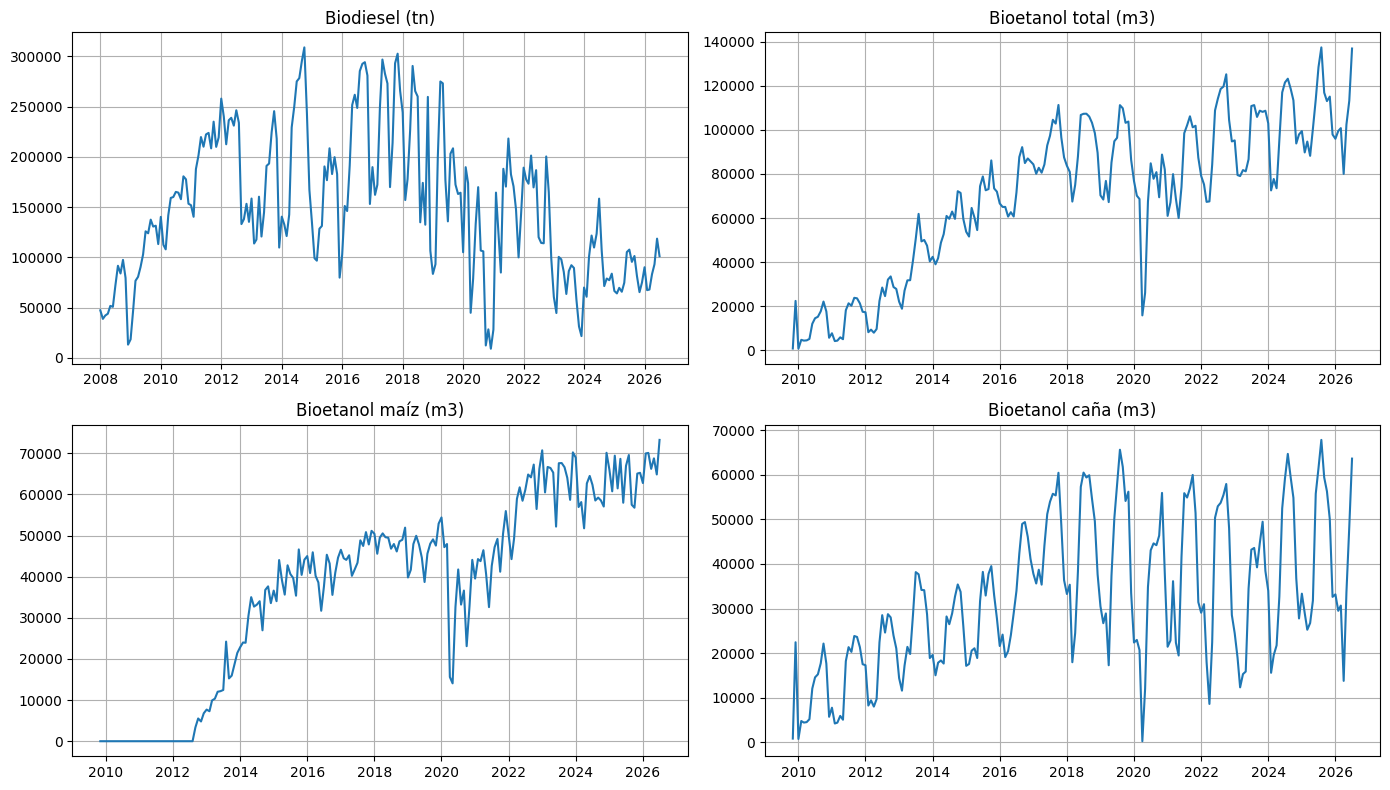

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (nom, s) in zip(axes.ravel(), series.items()):
    ax.plot(s.index, s.values)
    ax.set_title(nom)
plt.tight_layout(); plt.show()

## 3. Un problema estructural: el bioetanol de maíz arranca en 2012

La serie de maíz tiene 34 meses en cero al principio: no es que no se
produjo, es que **todavía no existían plantas de etanol de maíz**. La
primera producción real es de septiembre de 2012.

Consecuencia para el modelado: esos ceros no son datos a predecir, y
además rompen la transformación logarítmica. La serie de maíz hay que
recortarla a partir de su primer mes con producción.

In [4]:
maiz = be["produccion_maiz_m3"]
primer_maiz = maiz[maiz > 0].index.min()
print(f"Primer mes con producción de maíz: {primer_maiz:%Y-%m}")
print(f"Meses en cero (previos): {(maiz == 0).sum()}")

# Recorte sugerido
maiz_real = maiz.loc[primer_maiz:]
print(f"Serie de maíz utilizable: {len(maiz_real)} meses "
      f"({maiz_real.index.min():%Y-%m} a {maiz_real.index.max():%Y-%m})")

Primer mes con producción de maíz: 2012-09
Meses en cero (previos): 34
Serie de maíz utilizable: 167 meses (2012-09 a 2026-07)


## 4. Transformación: nivel vs. logaritmo vs. variación mensual

Las series crecen de forma multiplicativa (el bioetanol total se multiplicó
por ~160 desde 2009). En nivel, la varianza crece con la escala. El
**logaritmo** estabiliza eso, y la **variación mensual en log**
(`log(x_t) - log(x_{t-1})`) es aproximadamente la tasa de cambio mensual,
que es lo que publica BCR en el IACA.

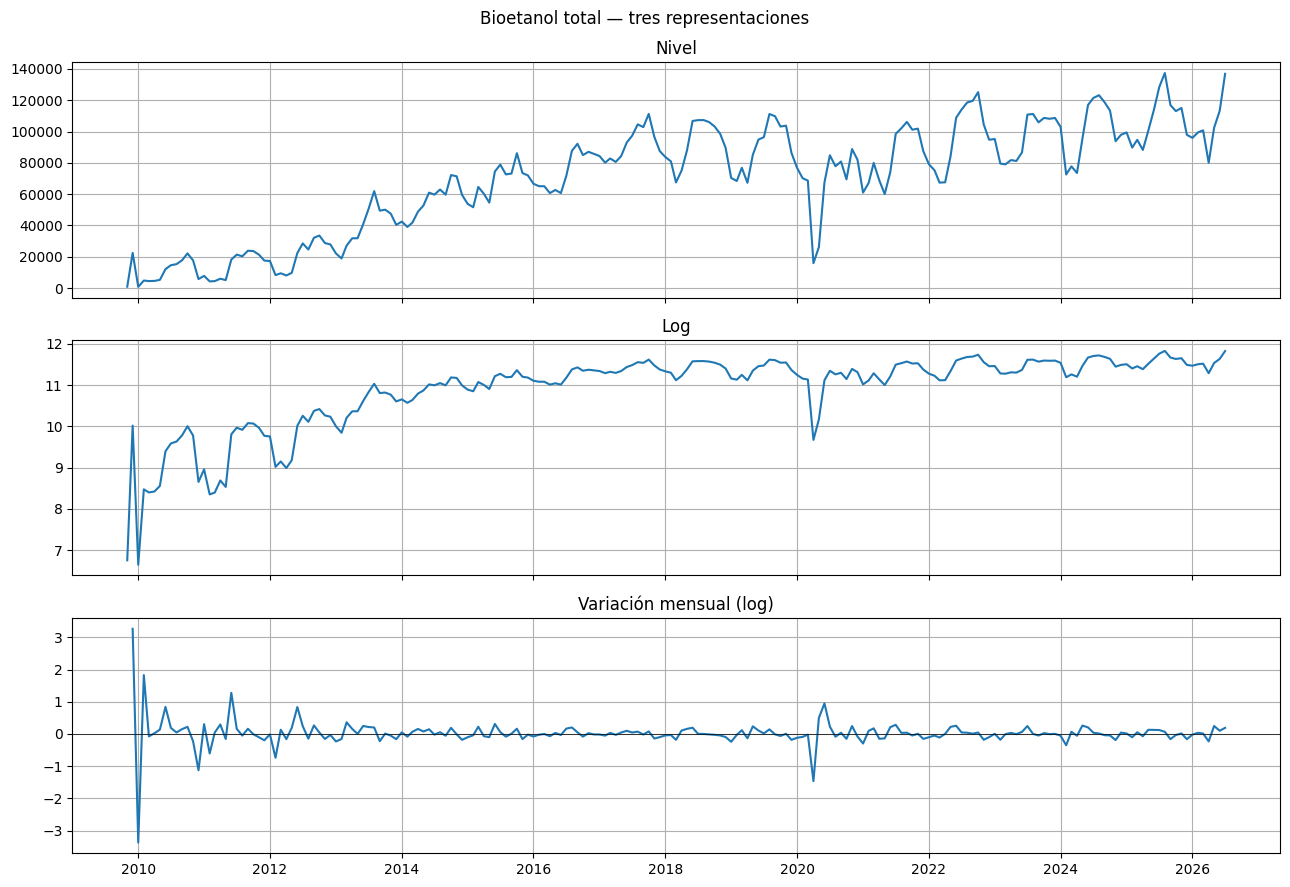

In [5]:
def var_log(s):
    return np.log(s.replace(0, np.nan)).diff().dropna()

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
s = series["Bioetanol total (m3)"]
axes[0].plot(s.index, s.values);              axes[0].set_title("Nivel")
axes[1].plot(s.index, np.log(s.values));      axes[1].set_title("Log")
vl = var_log(s)
axes[2].plot(vl.index, vl.values);            axes[2].set_title("Variación mensual (log)")
axes[2].axhline(0, color="k", lw=0.5)
plt.suptitle("Bioetanol total — tres representaciones"); plt.tight_layout(); plt.show()

## 5. Descomposición STL

Separa cada serie (en log, desde 2016 para evitar el arranque inestable del
bioetanol) en tendencia, estacionalidad y residuo. La **fuerza** de cada
componente resume cuánto pesa: cerca de 1 es fuerte, cerca de 0 es
despreciable.

In [6]:
def fuerzas(s_log):
    res = STL(s_log, period=12, robust=True).fit()
    Fs = max(0, 1 - res.resid.var() / (res.resid + res.seasonal).var())
    Ft = max(0, 1 - res.resid.var() / (res.resid + res.trend).var())
    return res, Fs, Ft

print("Fuerza estacional / tendencia (STL en log, 2016 en adelante):")
for nom, s in series.items():
    sl = np.log(s.loc["2016":].replace(0, np.nan)).dropna()
    if len(sl) < 36:
        continue
    _, Fs, Ft = fuerzas(sl)
    print(f"  {nom:24s}: estacional={Fs:.2f}  tendencia={Ft:.2f}")

Fuerza estacional / tendencia (STL en log, 2016 en adelante):
  Biodiesel (tn)          : estacional=0.15  tendencia=0.44
  Bioetanol total (m3)    : estacional=0.42  tendencia=0.36
  Bioetanol maíz (m3)     : estacional=0.01  tendencia=0.57
  Bioetanol caña (m3)     : estacional=0.58  tendencia=0.16


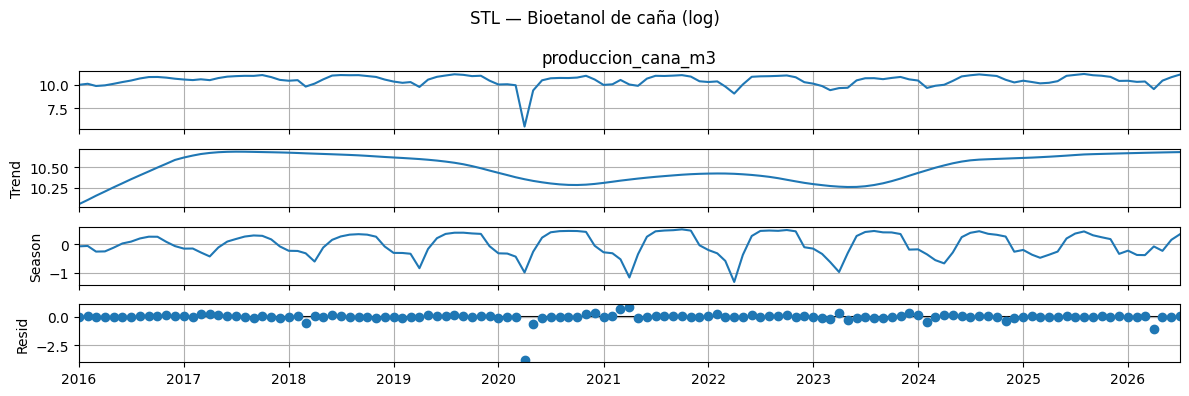

In [7]:
# Descomposición completa del bioetanol de caña (el más estacional)
sl = np.log(series["Bioetanol caña (m3)"].loc["2016":]).dropna()
STL(sl, period=12, robust=True).fit().plot()
plt.suptitle("STL — Bioetanol de caña (log)"); plt.tight_layout(); plt.show()

## 6. Estacionalidad: la zafra de la caña

El perfil estacional (producción promedio por mes, 2016-2019) muestra la
diferencia clave entre las dos materias primas:

- **Caña**: sigue la zafra azucarera. Piso de enero a abril, pico de julio
  a octubre.
- **Maíz**: produce parejo todo el año, sin estacionalidad.
- **Biodiesel**: estacionalidad leve.

Por eso conviene modelar el bioetanol de maíz y de caña por separado en
lugar de solo el total.

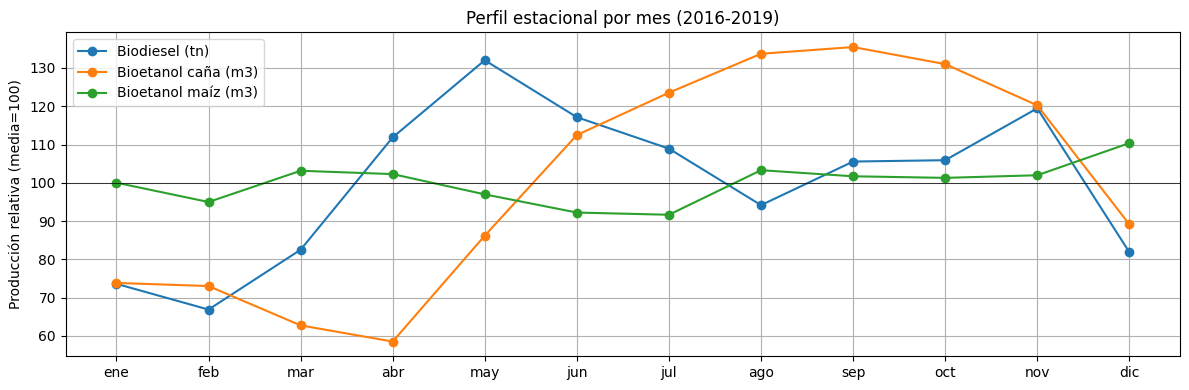

In [8]:
meses = ["ene","feb","mar","abr","may","jun","jul","ago","sep","oct","nov","dic"]
fig, ax = plt.subplots(figsize=(12, 4))
for nom in ["Biodiesel (tn)", "Bioetanol caña (m3)", "Bioetanol maíz (m3)"]:
    tramo = series[nom].loc["2016":"2019"]
    perfil = tramo.groupby(tramo.index.month).mean()
    perfil = perfil / perfil.mean() * 100
    ax.plot(meses, perfil.values, marker="o", label=nom)
ax.axhline(100, color="k", lw=0.5)
ax.set_ylabel("Producción relativa (media=100)")
ax.set_title("Perfil estacional por mes (2016-2019)")
ax.legend(); plt.tight_layout(); plt.show()

## 7. Estacionariedad (ADF y KPSS)

Dos tests complementarios, sobre la serie en nivel y en variación mensual:
- **ADF**: H0 = no estacionaria. p < 0.05 ⇒ estacionaria.
- **KPSS**: H0 = estacionaria. p > 0.05 ⇒ estacionaria.

Se aplican a cada serie (el maíz recortado desde 2012).

In [9]:
def tests(s, etq):
    s = s.dropna()
    p_adf = adfuller(s, autolag="AIC")[1]
    p_kpss = kpss(s, regression="c", nlags="auto")[1]
    print(f"  {etq:16s}: ADF p={p_adf:.3f} ({'estac.' if p_adf<0.05 else 'NO'})"
          f"  | KPSS p={p_kpss:.3f} ({'estac.' if p_kpss>0.05 else 'NO'})")

objetivo = {
    "Biodiesel":       bd["produccion_tn"],
    "Bioetanol total": be["produccion_total_m3"],
    "Bioetanol maíz":  maiz_real,
    "Bioetanol caña":  be["produccion_cana_m3"],
}
for nom, s in objetivo.items():
    print(nom)
    tests(s, "nivel")
    tests(var_log(s), "variación log")

Biodiesel
  nivel           : ADF p=0.299 (NO)  | KPSS p=0.034 (NO)
  variación log   : ADF p=0.000 (estac.)  | KPSS p=0.100 (estac.)
Bioetanol total
  nivel           : ADF p=0.512 (NO)  | KPSS p=0.010 (NO)
  variación log   : ADF p=0.077 (NO)  | KPSS p=0.100 (estac.)
Bioetanol maíz
  nivel           : ADF p=0.223 (NO)  | KPSS p=0.010 (NO)
  variación log   : ADF p=0.000 (estac.)  | KPSS p=0.085 (estac.)
Bioetanol caña
  nivel           : ADF p=0.214 (NO)  | KPSS p=0.010 (NO)
  variación log   : ADF p=0.000 (estac.)  | KPSS p=0.100 (estac.)


/tmp/ipykernel_483/183714398.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  p_kpss = kpss(s, regression="c", nlags="auto")[1]
/tmp/ipykernel_483/183714398.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  p_kpss = kpss(s, regression="c", nlags="auto")[1]
/tmp/ipykernel_483/183714398.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  p_kpss = kpss(s, regression="c", nlags="auto")[1]
/tmp/ipykernel_483/183714398.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  p_kpss = kpss(s, regression="c", nlags

## 8. Autocorrelación (ACF y PACF)

Sobre la variación mensual en log, para orientar los órdenes de un modelo
ARIMA/SARIMAX. Picos en los rezagos 12, 24 indicarían estacionalidad anual.

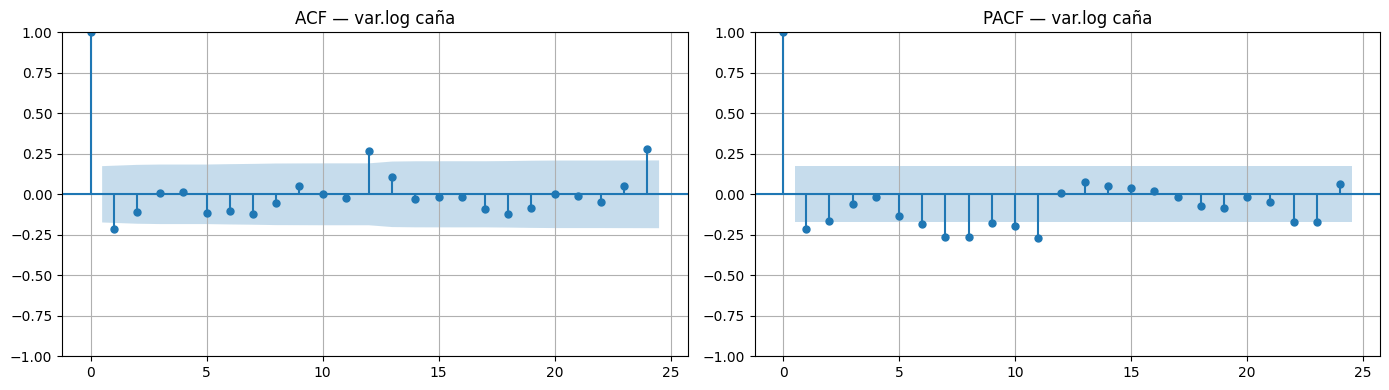

In [10]:
vl = var_log(series["Bioetanol caña (m3)"]).loc["2016":]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(vl, lags=24, ax=axes[0]); axes[0].set_title("ACF — var.log caña")
plot_pacf(vl, lags=24, ax=axes[1]); axes[1].set_title("PACF — var.log caña")
plt.tight_layout(); plt.show()

## 9. Outliers y quiebres

Los saltos mensuales más grandes (en variación log) coinciden con eventos
conocidos:
- **2020 (pandemia)**: caída y recuperación bruscas en todas las series, muy
  marcadas en caña (parada de ingenios).
- **Arranque del bioetanol (2009-2012)**: variaciones enormes por partir de
  valores casi nulos.
- **Cambios de corte obligatorio**: afectan el nivel de producción.

In [11]:
print("Mayores saltos mensuales por serie (|variación log|):")
for nom, s in objetivo.items():
    vl = var_log(s)
    top = vl.abs().sort_values(ascending=False).head(4)
    fechas = ", ".join(f"{f:%Y-%m} ({vl.loc[f]:+.2f})" for f in top.index)
    print(f"  {nom:16s}: {fechas}")

Mayores saltos mensuales por serie (|variación log|):
  Biodiesel       : 2020-10 (-2.15), 2008-12 (-1.80), 2021-02 (+1.77), 2020-04 (-1.36)
  Bioetanol total : 2010-01 (-3.37), 2009-12 (+3.26), 2010-02 (+1.83), 2020-04 (-1.46)
  Bioetanol maíz  : 2020-04 (-1.12), 2020-06 (+0.84), 2013-08 (+0.66), 2012-10 (+0.49)
  Bioetanol caña  : 2020-04 (-4.35), 2020-05 (+3.80), 2010-01 (-3.37), 2009-12 (+3.26)


## 10. Heterocedasticidad: la volatilidad cambia en el tiempo

El desvío de la variación mensual no es constante: es mucho más alto en el
arranque del bioetanol y en 2020 que en los períodos estables. Esto importa
para el modelado: un modelo que asume varianza constante (como el ARIMA
estándar) va a subestimar el error en los tramos turbulentos.

In [12]:
tramos = [("2009","2015"), ("2016","2019"), ("2020","2020"), ("2021","2026")]
print(f"{'Serie':16s} " + " ".join(f"{a}-{b[2:]:>4s}" for a,b in tramos))
for nom, s in objetivo.items():
    vl = var_log(s)
    fila = "  ".join(f"{vl.loc[a:b].std():.2f}" if len(vl.loc[a:b]) else "  - "
                     for a,b in tramos)
    print(f"{nom:16s}   {fila}")

Serie            2009-  15 2016-  19 2020-  20 2021-  26
Biodiesel          0.24  0.32  0.91  0.41
Bioetanol total    0.67  0.10  0.56  0.13
Bioetanol maíz     0.20  0.10  0.48  0.12
Bioetanol caña     0.68  0.25  1.78  0.37


## 11. Conclusiones y propuesta de transformación

**Hallazgos**

1. Las cuatro series son **no estacionarias en nivel** (crecen de forma
   multiplicativa). La **variación mensual en log** las vuelve estacionarias
   (salvo el bioetanol total, que queda en el límite).
2. El **bioetanol de maíz** empieza a producirse en 2012: sus primeros 34
   meses en cero deben excluirse.
3. **Estacionalidad** fuerte solo en la **caña** (zafra, pico jul-oct). El
   maíz no tiene; el biodiesel, leve.
4. **Heterocedasticidad** clara: la volatilidad es mucho mayor en el
   arranque del bioetanol y en 2020.
5. **Outliers** concentrados en 2020 (pandemia) y en el arranque del
   bioetanol.

**Propuesta de transformación por serie**

| Serie | Transformación | Estacionalidad | Período de entrenamiento |
|---|---|---|---|
| Biodiesel | log + variación mensual | leve (opcional) | desde 2008 |
| Bioetanol total | log + variación mensual | media | desde 2013 (post-arranque) |
| Bioetanol maíz | log + variación mensual | no | desde 2012-09 |
| Bioetanol caña | log + variación mensual | sí (período 12) | desde 2013 |

**Para el modelado (Etapa 4)**

- Modelar la **tasa de cambio mensual en log**, no el nivel, para controlar
  tendencia y heterocedasticidad. Reconstruir el nivel al final.
- Tratar **maíz y caña por separado**; el total es la suma.
- Incluir **componente estacional** solo donde el STL lo justifica (caña).
- Marcar 2020 con una **dummy** o evaluar su impacto aparte.
- Decidir el inicio del período de entrenamiento por serie (no todas
  arrancan bien en 2008).